# Chapter 21. Pivot Tables

## 21.1 Motivating Pivot Tables

For the examples in this section, we’ll use the database of passengers on the Titanic,
available through the Seaborn library

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [24]:
print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### groupby survival rate by sex

In [25]:
print(titanic.groupby('sex')[['survived']].mean())

        survived
sex             
female  0.742038
male    0.188908


### Survival by sex + group

In [26]:
print(titanic.groupby(['sex', 'class'])[['survived']].mean().unstack())

        survived                    
class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


## 21.2 Pivot Table Syntax

Here is the equivalent to the preceding operation using the DataFrame.pivot_table
method:

In [27]:
# same result by pivot_table
print(titanic.pivot_table('survived', index='sex', columns='class', aggfunc='mean'))

class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


### Main syntax

In [28]:
# pd.pivot_table(data, values=None, index=None, columns=None,
#               aggfunc='mean', fill_value=None, margins=False,
#               dropna=True, margins_name='All', observed=False, sort=True)

| 매개변수 | 설명 | 기본값 |
|----------|------|--------|
| `data` | DataFrame | **필수** |
| `values` | 집계할 렬 | `None` |
| `index` | 행 index로 사용할 렬 | `None` |
| `columns` | 렬 index로 사용할 렬 | `None` |
| `aggfunc` | 집계 함수 | `'mean'` |
| `fill_value` | NaN 대체 값 | `None` |
| `margins` | 전체 합계/평균 추가 | `False` |
| `margins_name` | 마진 렬 이름 | `'All'` |

## 21.3 Multilevel Pivot Tables

### 나이를 추가한 3차원분석

In [29]:
# 나이를 0-18, 18-80 구간으로 나눔
age = pd.cut(titanic['age'], [0, 18, 80])

print(titanic.pivot_table('survived', ['sex', age], 'class'))

class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663


### 료금을 추가한 4차원분석

In [30]:
# 료금을 2개 구간으로 나눔
fare = pd.qcut(titanic['fare'], 2)

print(titanic.pivot_table('survived', ['sex', age], [fare, 'class']))

fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870          0.800000   
       (18, 80]              0.0  0.098039  0.125000          0.391304   

fare                                 
class              Second     Third  
sex    age                           
female (0, 18]   1.000000  0.318182  
       (18, 80]  0.914286  0.391304  
male   (0, 18]   0.818182  0.178571  
       (18, 80]  0.030303  0.192308  


## 21.4 Additional Pivot Table Options

### 21.4.1 여러 집계 함수 사용 (aggfunc)

In [31]:
print(titanic.pivot_table(index='sex', columns='class',
                          aggfunc={'survived': 'sum', 'fare': 'mean'}))

              fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47


### 21.4.2 전체 합계 추가 (margins=True)

In [32]:
print(titanic.pivot_table('survived', index='sex', columns='class', margins=True))

class      First    Second     Third       All
sex                                           
female  0.968085  0.921053  0.500000  0.742038
male    0.368852  0.157407  0.135447  0.188908
All     0.629630  0.472826  0.242363  0.383838


## 21.5 Example: Birthrate data

### Data load

In [33]:
births = pd.read_csv('https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv')

births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


### 19.5.1 년대(decade)별 성별 출생 수

In [36]:
births['decade'] = 10 * (births['year'] // 10)

print(births.pivot_table('births', index='decade', columns='gender', aggfunc='sum'))

gender         F         M
decade                    
1960     1753634   1846572
1970    16263075  17121550
1980    18310351  19243452
1990    19479454  20420553
2000    18229309  19106428


### 19.5.2 Visualization

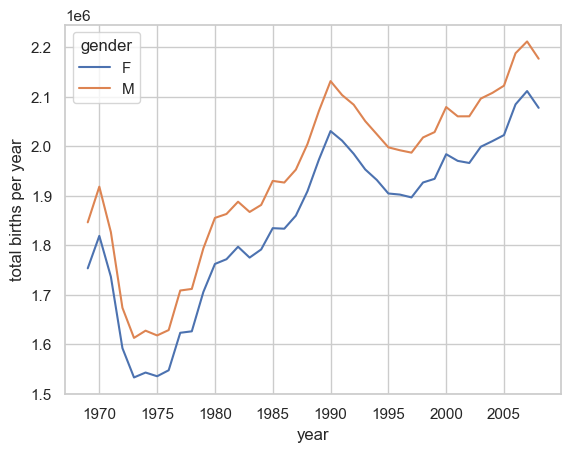

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

births.pivot_table('births', index='year', columns='gender', aggfunc='sum').plot()
plt.ylabel('total births per year')
plt.show()

### 19.5.3 이상치 제거 (시그마 클리핑)

In [41]:
# 이상치 제거를 위한 통계 계산
quartiles = np.percentile(births['births'], [25, 50, 75])
mu = quartiles[1]
sig = 0.74 * (quartiles[2] - quartiles[0])

# 이상치 filtering
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

# day 렬을 정수로 변환
births['day'] = births['day'].astype(int)

# Creating date indexing
births.index = pd.to_datetime(10000 * births.year + 100 * births.month + births.day,
                              format='%Y%m%d')
births['dayofweek'] = births.index.dayofweek

### 19.5.4 요일별 출생 수 (년대별)

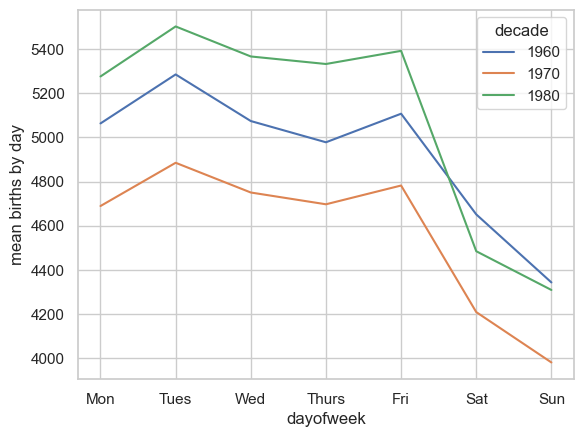

In [43]:
import matplotlib as mpl

births.pivot_table('births', index='dayofweek',
                   columns='decade', aggfunc='mean').plot()
plt.gca().set(xticks=range(7),
              xticklabels=['Mon', 'Tues', 'Wed', 'Thurs',
                           'Fri', 'Sat', 'Sun'])
plt.ylabel('mean births by day')
plt.show()

### 19.5.5 날자별 평균 출생수

In [47]:
# 월, 일별로 group화
births_by_date = births.pivot_table('births', [births.index.month, births.index.day])
print(births_by_date.head())

       births
1 1  4009.225
  2  4247.400
  3  4500.900
  4  4571.350
  5  4603.625


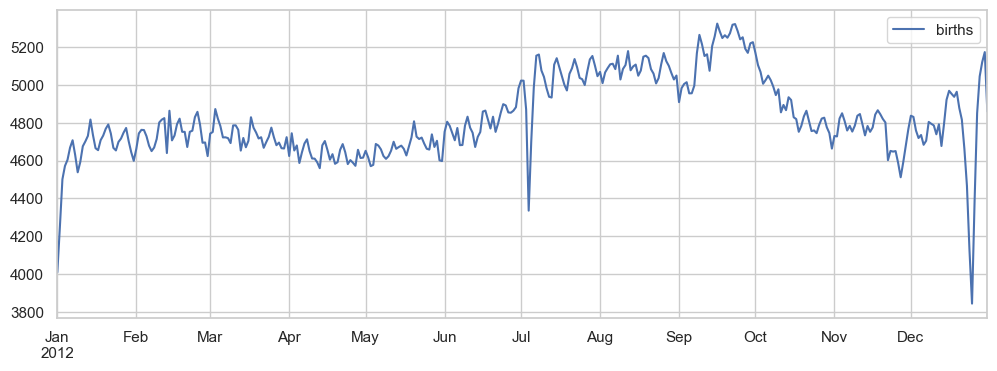

In [48]:
from datetime import datetime

# 시각화를 위해 날자로 변환
births_by_date.index = [datetime(2012, month, day) for (month, day) in births_by_date.index]

# 플롯
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax)
plt.show()